This notebook analyzes the spectrum from the results of the Super-Resolution simulation `256_set3_b`. It compares the images from the AI model and a simple bicubic interpolation.

Details of the simulation (and dataset) parameters are stored in `\param_simualtions\256_set3_b`


In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.image import imread
from PIL import Image

import pixell
from pixell import enmap
from pixell import curvedsky

In [2]:
def get_cl_from_pixell_map(imap,lmax):
    # get an apodized mask, multiply the map before doing map2alm
    #we smooth (apodize) the boundaries which we define as a 10% of the pixels
    boundary=int(0.1*imap.shape[0])
    taper_mask = enmap.apod(pixell.enmap.ones(imap.shape, imap.wcs), width=boundary)
    alm_taper = curvedsky.map2alm(taper_mask * imap, lmax=lmax)

    # get the correction factor that accounts for the power lost due to only observing a
    # fraction of the sky
    # enmap.pixsizemap is a map of all the physical pixel areas in steradians
    w2 = np.sum(taper_mask.pixsizemap() * taper_mask**2) / (4*np.pi)

    #alm = pixell.curvedsky.map2alm(imap,lmax=lmax)
    # squaring and averaging over m is done by the alm2cl function
    cl=curvedsky.alm2cl(alm_taper)/w2
    return cl

## Read the images from the simulation (and dataset)

In [3]:
nside = 256 #that's what was used on the data generation (it was the same as the image size)
nside_small = 64 #that's the size of the low-res images

In [4]:
root_folder='results_256_set3_b/'
file_map=root_folder+'256_set3_map.hdf'
file_img_hr=root_folder+'88000_3_1_hr.png'
file_img_sr=root_folder+'88000_3_1_sr.png'
file_img_lr=root_folder+'88000_3_1_inf.png' #this is the bicubic upsampled image
file_img_lr_small=root_folder+'88000_3_1_lr.png' #this is the low-res image
#file_img_training=root_folder+'example_image_256_set3_training_set.png' #a random training image (256x256 set3)

In [5]:
lmax=3*nside-1
lmax_small=3*nside_small-1
print('lmax is:',lmax)
print('nside is:',nside)

lmax is: 767
nside is: 256


In [6]:
#read the refernece map (contains the wcs)
ref_map= enmap.read_map(file_map,fmt='hdf')

In [7]:
img_hr = Image.open(file_img_hr).convert('L')
img_sr = Image.open(file_img_sr).convert('L')
img_lr = Image.open(file_img_lr).convert('L')
img_lr_small = Image.open(file_img_lr_small).convert('L')

In [8]:
img_hr_np=np.asarray(img_hr)
img_sr_np=np.asarray(img_sr)
img_lr_np=np.asarray(img_lr)
img_lr_small_np=np.asarray(img_lr_small)
#img_train_np=np.asarray(img_train)

In [9]:
print(np.shape(img_hr_np))
print(np.shape(img_lr_small_np))

(256, 256)
(64, 64)


In [10]:
#create the map from the array plus the wcs from the reference map
hr_map=enmap.ndmap(img_hr_np[:,:],wcs=ref_map.wcs)
sr_map=enmap.ndmap(img_sr_np[:,:],wcs=ref_map.wcs)
lr_map=enmap.ndmap(img_lr_np[:,:],wcs=ref_map.wcs)
#lr_small_map=enmap.ndmap(img_lr_small_np[:,:],wcs=ref_map.wcs)
#but the wcs for the small map should be different (going from 256 to 64 pixels)
#we need to get the new wcs by downgrading the original wcs
wcs_small=enmap.downgrade(hr_map,4).wcs
lr_small_map_down=enmap.ndmap(img_lr_small_np[:,:],wcs=wcs_small)

In [11]:
cl_hr=get_cl_from_pixell_map(hr_map[:,:],lmax)
cl_sr=get_cl_from_pixell_map(sr_map[:,:],lmax)
cl_lr=get_cl_from_pixell_map(lr_map[:,:],lmax)
#cl_lr_small=get_cl_from_pixell_map(lr_small_map[:,:],lmax)
cl_lr_small_down=get_cl_from_pixell_map(lr_small_map_down[:,:],lmax_small)

In [21]:
print(cl_hr[0])
print(cl_sr[0])
print(cl_lr[0])

53.6113562424985
67.6829386570417
53.62406760874436


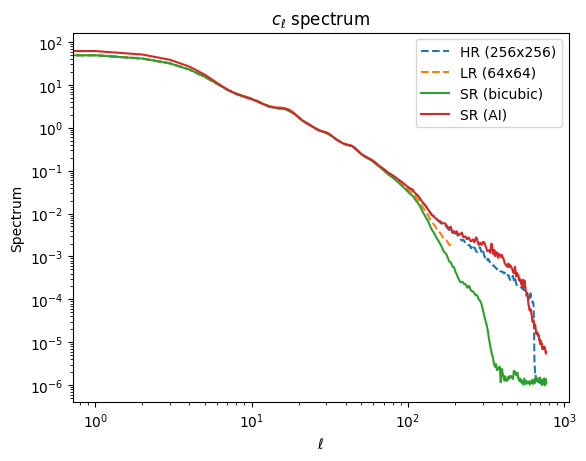

In [12]:
#plt.plot(cl_train,label='Random Training image (256x256)')
plt.plot(cl_hr,linestyle='--',label='HR (256x256)')
#plt.plot(cl_lr_small,label='LR (64x64) ') #was the using the wrong wcs
plt.plot(cl_lr_small_down,linestyle='--',label='LR (64x64)') #using the downgraded wcs
plt.plot(cl_lr,label='SR (bicubic)')
plt.plot(cl_sr,label='SR (AI)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$')
plt.ylabel('Spectrum')
plt.title(r'$c_\ell$ spectrum')
plt.legend()

In the above plot:
- HR: high resolution image, calculated directly from the pysm genereated images
- LR: low resolution 64x6. It was downscaled by Pytorch (from the flat 256x256 HR image) bu we used the reduced wcs to calculate the spectrum
- SR (bicubic): Pytorch upscale of the LR
- SR(AI): The results from using the SR model (note it was using the LR for training)

**Difference between SR(AI) and HR image**

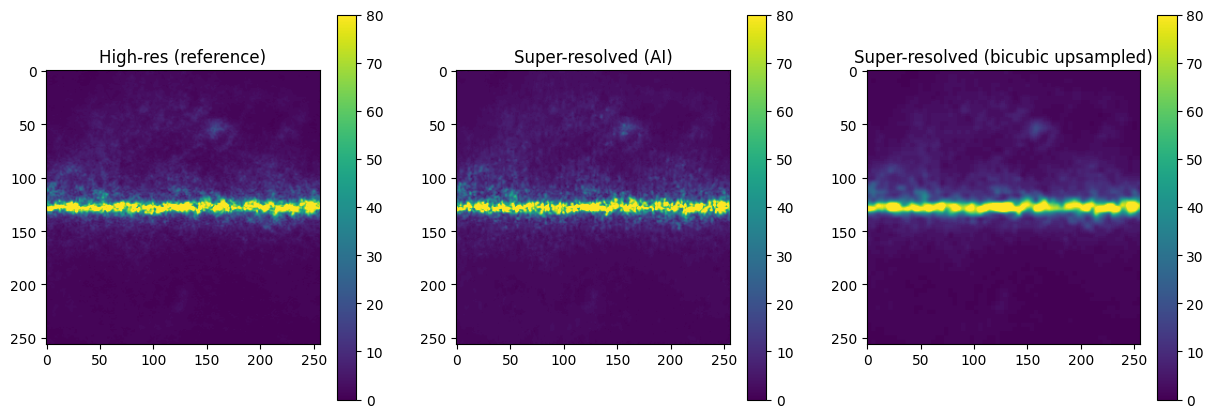

In [13]:
#plot the sr_map, hr_map and lr_map(super res with bicubic) one next to the other
max_scale=80
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title('High-res (reference)')
plt.imshow(hr_map,vmin=0,vmax=max_scale)
plt.colorbar()
plt.subplot(1,3,2)
plt.title('Super-resolved (AI)')
plt.imshow(sr_map,vmin=0,vmax=max_scale)
plt.colorbar()
plt.subplot(1,3,3)
plt.title('Super-resolved (bicubic upsampled)')
plt.imshow(lr_map,vmin=0,vmax=max_scale)
plt.colorbar()

(60.0, 200.0)

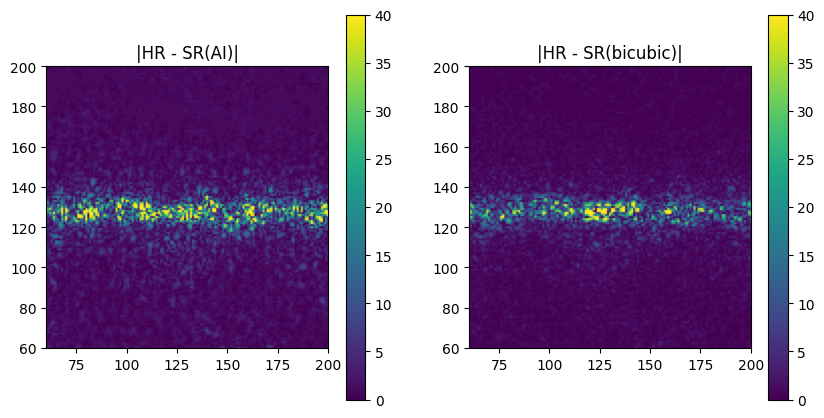

In [14]:
#calculate the absolute difference between hr_map and sr_map but takin inco account the uint8 type
diff_ai=np.abs(hr_map.astype(np.int16) - sr_map.astype(np.int16))
diff_bic=np.abs(hr_map.astype(np.int16) - lr_map.astype(np.int16))
plt.figure(figsize=(10,5))
min_lim=60
max_lim=200
max_val=40
plt.subplot(1,2,1)
plt.title('|HR - SR(AI)|')
plt.imshow(diff_ai,vmin=0,vmax=max_val)
plt.colorbar()
plt.xlim(min_lim,max_lim)
plt.ylim(min_lim,max_lim)
plt.subplot(1,2,2)
plt.title('|HR - SR(bicubic)|')
plt.imshow(diff_bic,vmin=0,vmax=max_val)
plt.colorbar()
plt.xlim(min_lim,max_lim)
plt.ylim(min_lim,max_lim)

### 2D interpolation
Here we will downgrade the HR image using pixell (instead of downgrading it with Pytorch/Pillow)

In [15]:
#smooth_map=enmap.smooth_gauss(hr_map,sigma=0.005)
factor =4 #from 256 to 64
smooth_map=enmap.downgrade_fft(hr_map,factor)

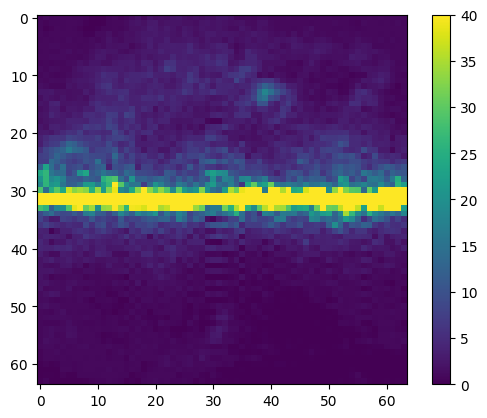

In [16]:
plt.imshow(smooth_map,vmin=0,vmax=40)
plt.colorbar()

In [17]:
cl_smooth=get_cl_from_pixell_map(smooth_map[:,:],lmax_small)

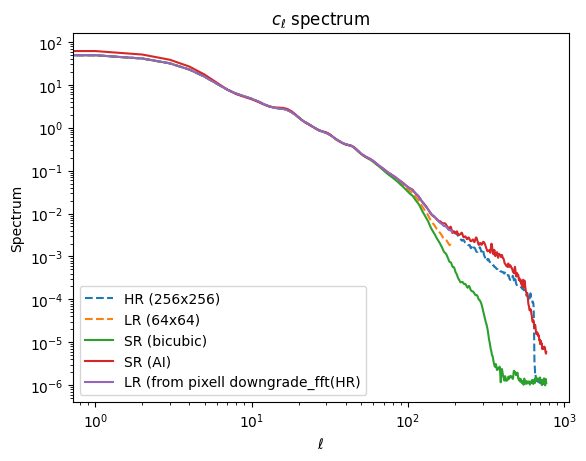

In [18]:
#plt.plot(cl_train,label='Random Training image (256x256)')
plt.plot(cl_hr,linestyle='--',label='HR (256x256)')
#plt.plot(cl_lr_small,label='LR (64x64) ') #was the using the wrong wcs
plt.plot(cl_lr_small_down,linestyle='--',label='LR (64x64)') #using the downgraded wcs
plt.plot(cl_lr,label='SR (bicubic)')
plt.plot(cl_sr,label='SR (AI)')
plt.plot(cl_smooth,label='LR (from pixell downgrade_fft(HR)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$')
plt.ylabel('Spectrum')
plt.title(r'$c_\ell$ spectrum')
#plt.ylim(1e-3,1e6)
plt.legend()